In [2]:
import pandas as pd
import numpy as np

train = pd.read_csv('Data/encode_train.csv')
test = pd.read_csv('Data/encode_test.csv')
valid = pd.read_csv('Data/encode_valid.csv')

In [3]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import average_precision_score, roc_auc_score

In [18]:
import sys
import os

# Add parent directory to path
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

In [6]:
bool_col = [
    'FirstTimeHomebuyerFlag',
    'SuperConformingFlag',
    'CreditScore_MissFLag',
    'OriginalDTI_MissFLag',
    'HighRiskCredit',
    'HighLTV',
    'HighDTI',
    'HighInterestRate',
    'LTV_MissFlag'
]

cat_col = [
    'NumberOfUnits',
    'OccupancyStatus',
    'Channel',
    'PropertyType',
    'LoanPurpose',
    'ProgramIndicator',
    'PropertyValMethod',
    'BalloonIndicator'
]

num_col = [
    'CreditScore',
    'MI_Pct',
    'OriginalDTI',
    'OriginalUPB',
    'OriginalLTV',
    'OriginalInterestRate',
    'OriginalLoanTerm',
    'NumberOfBorrowers',
    '0_1_UPB_Diff',
    '1_2_UPB_Diff',
    '2_3_UPB_Diff',
    '3_4_UPB_Diff',
    '4_5_UPB_Diff',
    '5_6_UPB_Diff',
    '6_7_UPB_Diff',
    '7_8_UPB_Diff',
    '8_9_UPB_Diff',
    '9_10_UPB_Diff',
    '10_11_UPB_Diff',
    '11_12_UPB_Diff',
    '12_13_UPB_Diff',
    'longest_unchanged_UPB',
    'avg_repayment_ratio',
    'pct_months_late',
    'Principal_reduction_rate',
    'Amortization_slope',
    'UPB_rebound_count',
    'UPB_autocorr',
    'UPB_skew',
    'UPB_kurtosis',
    'LTV_mean',
    'LTV_std',
    'LTV_slope',
    'LTV_rebound_count',
    'Interest_rate_std',
    'Interest_rate_slope',
    'Early_repayment_ratio',
    'CreditScore_LTV_Ratio',
    'CreditScore_DTI_Ratio',
    'LTV_DTI_Product',
    'DebtServiceRatio',
    'CompositeRiskScore',
    'OriginalLTV_delta',
    'MSA_freq_enc',
    'PropertyState_freq_enc',
    'SellerName_freq_enc',
    'ServicerName_freq_enc'
]

In [7]:
import copy
all_feature_dict = {}
for value in bool_col:
    all_feature_dict[value] = "bool"
for value in cat_col:
    all_feature_dict[value] = "cat"
for value in num_col:
    all_feature_dict[value] = "num"
all_feature_dict_copy = copy.deepcopy(all_feature_dict)

In [8]:
all_feature_dict_copy

{'FirstTimeHomebuyerFlag': 'bool',
 'SuperConformingFlag': 'bool',
 'CreditScore_MissFLag': 'bool',
 'OriginalDTI_MissFLag': 'bool',
 'HighRiskCredit': 'bool',
 'HighLTV': 'bool',
 'HighDTI': 'bool',
 'HighInterestRate': 'bool',
 'LTV_MissFlag': 'bool',
 'NumberOfUnits': 'cat',
 'OccupancyStatus': 'cat',
 'Channel': 'cat',
 'PropertyType': 'cat',
 'LoanPurpose': 'cat',
 'ProgramIndicator': 'cat',
 'PropertyValMethod': 'cat',
 'BalloonIndicator': 'cat',
 'CreditScore': 'num',
 'MI_Pct': 'num',
 'OriginalDTI': 'num',
 'OriginalUPB': 'num',
 'OriginalLTV': 'num',
 'OriginalInterestRate': 'num',
 'OriginalLoanTerm': 'num',
 'NumberOfBorrowers': 'num',
 '0_1_UPB_Diff': 'num',
 '1_2_UPB_Diff': 'num',
 '2_3_UPB_Diff': 'num',
 '3_4_UPB_Diff': 'num',
 '4_5_UPB_Diff': 'num',
 '5_6_UPB_Diff': 'num',
 '6_7_UPB_Diff': 'num',
 '7_8_UPB_Diff': 'num',
 '8_9_UPB_Diff': 'num',
 '9_10_UPB_Diff': 'num',
 '10_11_UPB_Diff': 'num',
 '11_12_UPB_Diff': 'num',
 '12_13_UPB_Diff': 'num',
 'longest_unchanged_UPB':

In [14]:
X_train = train[cat_col + num_col + bool_col]
X_valid = valid[cat_col + num_col + bool_col]
X_test = test.drop(columns="Id")

y_valid = valid[['index', 'target']]

### Greedy

In [20]:
from scipy.sparse import issparse
import pandas as pd
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.metrics import average_precision_score, roc_auc_score
from sklearn.svm import OneClassSVM
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif
from sklearn.preprocessing import StandardScaler, OneHotEncoder, MinMaxScaler
# from category_encoders import BinaryEncoder
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from pyod.models.ecod import ECOD
from pyod.models.copod import COPOD


def greedy_forward_selection(X_train, X_valid, y_valid, all_features, max_features=25):
    """
    Greedily add features one by one to maximize AP.
    """
    selected = []
    remaining = all_features.copy()
    best_ap = 0
    
    num_pipeline = Pipeline([
        ("scaler", MinMaxScaler())
    ])

    preprocess = ColumnTransformer(
        transformers=[("num", num_pipeline, all_features)],
        sparse_threshold=1.0,
    )
    
    X_train_prep = preprocess.fit_transform(X_train[all_features])
    X_valid_prep = preprocess.transform(X_valid[all_features])
    
    if issparse(X_train_prep):
        X_train_prep = X_train_prep.toarray()
        X_valid_prep = X_valid_prep.toarray()
    
    feature_to_idx = {f: i for i, f in enumerate(all_features)}
    
    print("Starting forward feature selection...\n")
    
    for round_num in range(max_features):
        best_feature = None
        best_round_ap = best_ap
        
        for feature in remaining:
            # Try adding this feature
            test_features = selected + [feature]
            test_indices = [feature_to_idx[f] for f in test_features]
            
            X_train_test = X_train_prep[:, test_indices]
            X_valid_test = X_valid_prep[:, test_indices]
            
            # Train and evaluate
            ocsvm = COPOD()
            ocsvm.fit(X_train_test)
            
            scores = ocsvm.decision_function(X_valid_test)
            # raw_anom = -scores
            min_v, max_v = np.min(scores), np.max(scores)
            anom_score = (scores - min_v) / (max_v - min_v + 1e-12)
            
            ap = average_precision_score(y_valid["target"], anom_score)
            roc_auc = roc_auc_score(y_valid["target"], anom_score)

            if ap > best_round_ap:
                print(f"AP={ap:.4f}, AUC={roc_auc:.4f}")
                best_round_ap = ap
                best_feature = feature
        
        if best_feature is None:
            print(f"\nNo improvement found. Stopping at {len(selected)} features.")
            break
        
        selected.append(best_feature)
        remaining.remove(best_feature)
        best_ap = best_round_ap
        
        print(f"Round {round_num+1}: Added '{best_feature}' -> AP={best_ap:.4f}")
    
    return selected

# Run forward selection
selected_features = greedy_forward_selection(X_train, X_valid, y_valid, num_col, max_features=15)
print(f"\nFinal selected features: {selected_features}")

Starting forward feature selection...

AP=0.2323, AUC=0.6548
Round 1: Added 'CreditScore' -> AP=0.2323
AP=0.2723, AUC=0.6676
AP=0.2737, AUC=0.6590
AP=0.2853, AUC=0.6825
Round 2: Added 'Early_repayment_ratio' -> AP=0.2853
AP=0.3056, AUC=0.6794
AP=0.3073, AUC=0.6707
AP=0.3178, AUC=0.6873
Round 3: Added 'UPB_rebound_count' -> AP=0.3178
AP=0.3294, AUC=0.6850
AP=0.3435, AUC=0.6738
Round 4: Added 'pct_months_late' -> AP=0.3435
AP=0.3439, AUC=0.6710
AP=0.3516, AUC=0.6794
Round 5: Added 'LTV_rebound_count' -> AP=0.3516
AP=0.3527, AUC=0.6958
Round 6: Added 'CompositeRiskScore' -> AP=0.3527
AP=0.3547, AUC=0.6919
Round 7: Added 'longest_unchanged_UPB' -> AP=0.3547

No improvement found. Stopping at 7 features.

Final selected features: ['CreditScore', 'Early_repayment_ratio', 'UPB_rebound_count', 'pct_months_late', 'LTV_rebound_count', 'CompositeRiskScore', 'longest_unchanged_UPB']


In [9]:
for col in cat_col:
    X_train[col] = X_train[col].astype(str)
    X_valid[col] = X_valid[col].astype(str)
    X_test[col] = X_test[col].astype(str)
for col in bool_col:
    X_train[col] = X_train[col].astype(int)
    X_valid[col] = X_valid[col].astype(int)
    X_test[col] = X_test[col].astype(int)

C:\Users\zheng\AppData\Local\Temp\ipykernel_16232\362698848.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train[col] = X_train[col].astype(str)
C:\Users\zheng\AppData\Local\Temp\ipykernel_16232\362698848.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_valid[col] = X_valid[col].astype(str)
C:\Users\zheng\AppData\Local\Temp\ipykernel_16232\362698848.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value in

## OneClassSVM greedy search

In [21]:
from utils import evaluate_outlier_model


selected_bool, selected_cat, selected_num = [], [], []
remaining = cat_col + bool_col + num_col
best_ap = 0
for round_num in range(25):
    best_feature= None
    best_round_ap = best_ap
    
    for feature in remaining:
        model  = OneClassSVM(
            kernel="rbf",     # RBF works well for non-linear anomalies
            nu=0.05,          # Upper bound on fraction of anomalies in training set
            gamma="scale"     # Kernel coefficient (can tune)
        )
        # print(feature)
        type_col = all_feature_dict_copy[feature]
        X_train_current = X_train[selected_bool + selected_cat + selected_num + [feature]]
        X_valid_current = X_valid[selected_bool + selected_cat + selected_num + [feature]]
        # print(X_train_current.head())
        if type_col == "cat":
            ap, roc_auc, scores = evaluate_outlier_model(
                model, X_train_current, X_valid_current, y_valid["target"], selected_cat+[feature], selected_num, selected_bool, True
            )
        elif type_col =="bool":
            ap, roc_auc, scores = evaluate_outlier_model(
                model, X_train_current, X_valid_current, y_valid["target"], selected_cat, selected_num, selected_bool+[feature],  True
            )
        else:
            ap, roc_auc, scores = evaluate_outlier_model(
            model, X_train_current, X_valid_current, y_valid["target"], selected_cat, selected_num+[feature], selected_bool,  True
            )
        if ap > best_round_ap:
                print(f"AP={ap:.4f}, AUC={roc_auc:.4f}")
                best_round_ap = ap
                best_feature = feature
    if best_feature is None:
            print(f"\nNo improvement found. Stopping at {len(selected_bool) + len(selected_cat)+ len(selected_num)} features.")
            break
    type_col = all_feature_dict_copy[best_feature]
    if type_col == "cat":
        selected_cat.append(best_feature)
    elif type_col =="bool":
        selected_bool.append(best_feature)
    else:
        selected_num.append(best_feature)
    remaining.remove(best_feature)
    best_ap = best_round_ap
    
    print(f"Round {round_num+1}: Added '{best_feature}' -> AP={best_ap:.4f}")

AP=0.1277, AUC=0.5054
AP=0.1338, AUC=0.5293
AP=0.1357, AUC=0.5300
AP=0.1685, AUC=0.5953
AP=0.1993, AUC=0.6063
AP=0.2205, AUC=0.6163
AP=0.2373, AUC=0.6122
AP=0.2379, AUC=0.6273
AP=0.2984, AUC=0.5973
Round 1: Added 'pct_months_late' -> AP=0.2984
AP=0.3863, AUC=0.7226
Round 2: Added 'NumberOfUnits' -> AP=0.3863
AP=0.3866, AUC=0.7155
AP=0.3951, AUC=0.7201
AP=0.4023, AUC=0.7214
Round 3: Added 'FirstTimeHomebuyerFlag' -> AP=0.4023

No improvement found. Stopping at 3 features.


## Isolation Forest

In [24]:
selected_bool, selected_cat, selected_num = [], [], []
remaining = cat_col + bool_col + num_col
best_ap = 0
for round_num in range(25):
    best_feature= None
    best_round_ap = best_ap
    
    for feature in remaining:
        model  = IsolationForest(
        n_estimators=200,
        max_samples="auto",
        contamination="auto",
        random_state=42,
        n_jobs=-1,
    )
        # print(feature)
        type_col = all_feature_dict_copy[feature]
        X_train_current = X_train[selected_bool + selected_cat + selected_num + [feature]]
        X_valid_current = X_valid[selected_bool + selected_cat + selected_num + [feature]]
        # print(X_train_current.head())
        if type_col == "cat":
            ap, roc_auc, scores = evaluate_outlier_model(
                model, X_train_current, X_valid_current, y_valid["target"], selected_cat+[feature], selected_num, selected_bool, True
            )
        elif type_col =="bool":
            ap, roc_auc, scores = evaluate_outlier_model(
                model, X_train_current, X_valid_current, y_valid["target"], selected_cat, selected_num, selected_bool+[feature],  True
            )
        else:
            ap, roc_auc, scores = evaluate_outlier_model(
            model, X_train_current, X_valid_current, y_valid["target"], selected_cat, selected_num+[feature], selected_bool,  True
            )
        if ap > best_round_ap:
                print(f"AP={ap:.4f}, AUC={roc_auc:.4f}")
                best_round_ap = ap
                best_feature = feature
    if best_feature is None:
            print(f"\nNo improvement found. Stopping at {len(selected_bool) + len(selected_cat)+ len(selected_num)} features.")
            break
    type_col = all_feature_dict_copy[best_feature]
    if type_col == "cat":
        selected_cat.append(best_feature)
    elif type_col =="bool":
        selected_bool.append(best_feature)
    else:
        selected_num.append(best_feature)
    remaining.remove(best_feature)
    best_ap = best_round_ap
    
    print(f"Round {round_num+1}: Added '{best_feature}' -> AP={best_ap:.4f}")

AP=0.1283, AUC=0.5054
AP=0.1301, AUC=0.5108
AP=0.1329, AUC=0.5280
AP=0.1474, AUC=0.5712
AP=0.2106, AUC=0.6446
AP=0.3456, AUC=0.6352
Round 1: Added 'pct_months_late' -> AP=0.3456
AP=0.3485, AUC=0.6577
AP=0.3719, AUC=0.6827
AP=0.3794, AUC=0.6655
Round 2: Added 'UPB_rebound_count' -> AP=0.3794
AP=0.3809, AUC=0.6889
Round 3: Added 'HighDTI' -> AP=0.3809
AP=0.3846, AUC=0.6948
AP=0.3860, AUC=0.6969
AP=0.3891, AUC=0.6951
Round 4: Added 'HighRiskCredit' -> AP=0.3891

No improvement found. Stopping at 4 features.


## LOF

In [23]:
selected_bool, selected_cat, selected_num = [], [], []
remaining = cat_col + bool_col + num_col
best_ap = 0
for round_num in range(25):
    best_feature= None
    best_round_ap = best_ap
    
    for feature in remaining:
        model  = LocalOutlierFactor(n_neighbors=8, novelty=True, leaf_size = 15)
        # print(feature)
        type_col = all_feature_dict_copy[feature]
        X_train_current = X_train[selected_bool + selected_cat + selected_num + [feature]]
        X_valid_current = X_valid[selected_bool + selected_cat + selected_num + [feature]]
        # print(X_train_current.head())
        if type_col == "cat":
            ap, roc_auc, scores = evaluate_outlier_model(
                model, X_train_current, X_valid_current, y_valid["target"], selected_cat+[feature], selected_num, selected_bool, True
            )
        elif type_col =="bool":
            ap, roc_auc, scores = evaluate_outlier_model(
                model, X_train_current, X_valid_current, y_valid["target"], selected_cat, selected_num, selected_bool+[feature],  True
            )
        else:
            ap, roc_auc, scores = evaluate_outlier_model(
            model, X_train_current, X_valid_current, y_valid["target"], selected_cat, selected_num+[feature], selected_bool,  True
            )
        if ap > best_round_ap:
                print(f"AP={ap:.4f}, AUC={roc_auc:.4f}")
                best_round_ap = ap
                best_feature = feature
    if best_feature is None:
            print(f"\nNo improvement found. Stopping at {len(selected_bool) + len(selected_cat)+ len(selected_num)} features.")
            break
    type_col = all_feature_dict_copy[best_feature]
    if type_col == "cat":
        selected_cat.append(best_feature)
    elif type_col =="bool":
        selected_bool.append(best_feature)
    else:
        selected_num.append(best_feature)
    remaining.remove(best_feature)
    best_ap = best_round_ap
    
    print(f"Round {round_num+1}: Added '{best_feature}' -> AP={best_ap:.4f}")

AP=0.1261, AUC=0.5000
AP=0.1263, AUC=0.5007
AP=0.1274, AUC=0.5007
AP=0.1280, AUC=0.5026
AP=0.1286, AUC=0.4950
AP=0.1358, AUC=0.4952
AP=0.1454, AUC=0.5111
AP=0.1919, AUC=0.5377
Round 1: Added 'pct_months_late' -> AP=0.1919
AP=0.1930, AUC=0.5379
AP=0.1945, AUC=0.5390
AP=0.2180, AUC=0.5551
AP=0.2231, AUC=0.5352
AP=0.2327, AUC=0.5409
AP=0.2342, AUC=0.5443
AP=0.2551, AUC=0.5525
Round 2: Added '7_8_UPB_Diff' -> AP=0.2551
AP=0.2554, AUC=0.5516
AP=0.2562, AUC=0.5607
AP=0.2743, AUC=0.5729
Round 3: Added '0_1_UPB_Diff' -> AP=0.2743
AP=0.2743, AUC=0.5729
Round 4: Added 'CreditScore_MissFLag' -> AP=0.2743
AP=0.2743, AUC=0.5729
Round 5: Added 'OriginalDTI_MissFLag' -> AP=0.2743

No improvement found. Stopping at 5 features.


# PYOD 
## ECOD

In [25]:
selected_bool, selected_cat, selected_num = [], [], []
remaining = cat_col + bool_col + num_col
best_ap = 0
for round_num in range(25):
    best_feature= None
    best_round_ap = best_ap
    
    for feature in remaining:
        model  = ECOD()
        # print(feature)
        type_col = all_feature_dict_copy[feature]
        X_train_current = X_train[selected_bool + selected_cat + selected_num + [feature]]
        X_valid_current = X_valid[selected_bool + selected_cat + selected_num + [feature]]
        # print(X_train_current.head())
        if type_col == "cat":
            ap, roc_auc, scores = evaluate_outlier_model(
                model, X_train_current, X_valid_current, y_valid["target"], selected_cat+[feature], selected_num, selected_bool, sparse_output=False, ispyod=True
            )
        elif type_col =="bool":
            ap, roc_auc, scores = evaluate_outlier_model(
                model, X_train_current, X_valid_current, y_valid["target"], selected_cat, selected_num, selected_bool+[feature],  sparse_output=False, ispyod=True
            )
        else:
            ap, roc_auc, scores = evaluate_outlier_model(
            model, X_train_current, X_valid_current, y_valid["target"], selected_cat, selected_num+[feature], selected_bool,  sparse_output=False, ispyod=True
            )
        if ap > best_round_ap:
                print(f"AP={ap:.4f}, AUC={roc_auc:.4f}")
                best_round_ap = ap
                best_feature = feature
    if best_feature is None:
            print(f"\nNo improvement found. Stopping at {len(selected_bool) + len(selected_cat)+ len(selected_num)} features.")
            break
    type_col = all_feature_dict_copy[best_feature]
    if type_col == "cat":
        selected_cat.append(best_feature)
    elif type_col =="bool":
        selected_bool.append(best_feature)
    else:
        selected_num.append(best_feature)
    remaining.remove(best_feature)
    best_ap = best_round_ap
    
    print(f"Round {round_num+1}: Added '{best_feature}' -> AP={best_ap:.4f}")

AP=0.1277, AUC=0.5054
AP=0.1301, AUC=0.5108
AP=0.1329, AUC=0.5280
AP=0.1474, AUC=0.5712
AP=0.1745, AUC=0.5924
AP=0.1889, AUC=0.6077
AP=0.2089, AUC=0.6267
AP=0.2353, AUC=0.6343
AP=0.3538, AUC=0.6569
Round 1: Added 'pct_months_late' -> AP=0.3538
AP=0.3559, AUC=0.6542
AP=0.3815, AUC=0.6792
Round 2: Added 'HighDTI' -> AP=0.3815
AP=0.3960, AUC=0.6868
Round 3: Added 'HighInterestRate' -> AP=0.3960

No improvement found. Stopping at 3 features.


## COPOD

In [26]:
selected_bool, selected_cat, selected_num = [], [], []
remaining = cat_col + bool_col + num_col
best_ap = 0
for round_num in range(25):
    best_feature= None
    best_round_ap = best_ap
    
    for feature in remaining:
        model  = COPOD()
        # print(feature)
        type_col = all_feature_dict_copy[feature]
        X_train_current = X_train[selected_bool + selected_cat + selected_num + [feature]]
        X_valid_current = X_valid[selected_bool + selected_cat + selected_num + [feature]]
        # print(X_train_current.head())
        if type_col == "cat":
            ap, roc_auc, scores = evaluate_outlier_model(
                model, X_train_current, X_valid_current, y_valid["target"], selected_cat+[feature], selected_num, selected_bool, sparse_output=False, ispyod=True
            )
        elif type_col =="bool":
            ap, roc_auc, scores = evaluate_outlier_model(
                model, X_train_current, X_valid_current, y_valid["target"], selected_cat, selected_num, selected_bool+[feature],  sparse_output=False, ispyod=True
            )
        else:
            ap, roc_auc, scores = evaluate_outlier_model(
            model, X_train_current, X_valid_current, y_valid["target"], selected_cat, selected_num+[feature], selected_bool,  sparse_output=False, ispyod=True
            )
        if ap > best_round_ap:
                print(f"AP={ap:.4f}, AUC={roc_auc:.4f}")
                best_round_ap = ap
                best_feature = feature
    if best_feature is None:
            print(f"\nNo improvement found. Stopping at {len(selected_bool) + len(selected_cat)+ len(selected_num)} features.")
            break
    type_col = all_feature_dict_copy[best_feature]
    if type_col == "cat":
        selected_cat.append(best_feature)
    elif type_col =="bool":
        selected_bool.append(best_feature)
    else:
        selected_num.append(best_feature)
    remaining.remove(best_feature)
    best_ap = best_round_ap
    
    print(f"Round {round_num+1}: Added '{best_feature}' -> AP={best_ap:.4f}")

AP=0.1277, AUC=0.5054
AP=0.1301, AUC=0.5108
AP=0.1329, AUC=0.5280
AP=0.1474, AUC=0.5712
AP=0.2323, AUC=0.6548
Round 1: Added 'CreditScore' -> AP=0.2323
AP=0.2426, AUC=0.6821
AP=0.2723, AUC=0.6676
AP=0.2737, AUC=0.6590
AP=0.2853, AUC=0.6825
Round 2: Added 'Early_repayment_ratio' -> AP=0.2853
AP=0.2946, AUC=0.7015
AP=0.3056, AUC=0.6794
AP=0.3073, AUC=0.6707
AP=0.3178, AUC=0.6873
Round 3: Added 'UPB_rebound_count' -> AP=0.3178
AP=0.3181, AUC=0.6911
AP=0.3269, AUC=0.7034
AP=0.3294, AUC=0.6850
AP=0.3435, AUC=0.6738
Round 4: Added 'pct_months_late' -> AP=0.3435
AP=0.3524, AUC=0.6897
Round 5: Added 'HighDTI' -> AP=0.3524
AP=0.3598, AUC=0.6978
AP=0.3603, AUC=0.6948
Round 6: Added 'LTV_rebound_count' -> AP=0.3603
AP=0.3658, AUC=0.7025
Round 7: Added 'HighInterestRate' -> AP=0.3658

No improvement found. Stopping at 7 features.


## QMCD

In [29]:
from pyod.models.qmcd import QMCD

selected_bool, selected_cat, selected_num = [], [], []
remaining = cat_col + bool_col + num_col
best_ap = 0
for round_num in range(25):
    best_feature= None
    best_round_ap = best_ap
    
    for feature in remaining:
        model  = QMCD()
        # print(feature)
        type_col = all_feature_dict_copy[feature]
        X_train_current = X_train[selected_bool + selected_cat + selected_num + [feature]]
        X_valid_current = X_valid[selected_bool + selected_cat + selected_num + [feature]]
        # print(X_train_current.head())
        if type_col == "cat":
            ap, roc_auc, scores = evaluate_outlier_model(
                model, X_train_current, X_valid_current, y_valid["target"], selected_cat+[feature], selected_num, selected_bool, sparse_output=False, ispyod=True
            )
        elif type_col =="bool":
            ap, roc_auc, scores = evaluate_outlier_model(
                model, X_train_current, X_valid_current, y_valid["target"], selected_cat, selected_num, selected_bool+[feature],  sparse_output=False, ispyod=True
            )
        else:
            ap, roc_auc, scores = evaluate_outlier_model(
            model, X_train_current, X_valid_current, y_valid["target"], selected_cat, selected_num+[feature], selected_bool,  sparse_output=False, ispyod=True
            )
        if ap > best_round_ap:
                print(f"AP={ap:.4f}, AUC={roc_auc:.4f}")
                best_round_ap = ap
                best_feature = feature
    if best_feature is None:
            print(f"\nNo improvement found. Stopping at {len(selected_bool) + len(selected_cat)+ len(selected_num)} features.")
            break
    type_col = all_feature_dict_copy[best_feature]
    if type_col == "cat":
        selected_cat.append(best_feature)
    elif type_col =="bool":
        selected_bool.append(best_feature)
    else:
        selected_num.append(best_feature)
    remaining.remove(best_feature)
    best_ap = best_round_ap
    
    print(f"Round {round_num+1}: Added '{best_feature}' -> AP={best_ap:.4f}")

C:\Users\zheng\anaconda3\envs\IS5126\Lib\site-packages\pyod\models\qmcd.py:107: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  skew = stats.skew(scores)
C:\Users\zheng\anaconda3\envs\IS5126\Lib\site-packages\pyod\models\qmcd.py:108: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  kurt = stats.kurtosis(scores)


AP=0.1261, AUC=0.5000


C:\Users\zheng\anaconda3\envs\IS5126\Lib\site-packages\pyod\models\qmcd.py:107: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  skew = stats.skew(scores)
C:\Users\zheng\anaconda3\envs\IS5126\Lib\site-packages\pyod\models\qmcd.py:108: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  kurt = stats.kurtosis(scores)
C:\Users\zheng\anaconda3\envs\IS5126\Lib\site-packages\pyod\models\qmcd.py:107: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  skew = stats.skew(scores)
C:\Users\zheng\anaconda3\envs\IS5126\Lib\site-packages\pyod\models\qmcd.py:108: RuntimeWarning: Precision loss occurred in moment calculation due to catastroph

AP=0.2375, AUC=0.6559
Round 1: Added 'CreditScore' -> AP=0.2375
AP=0.3364, AUC=0.6801
Round 2: Added 'pct_months_late' -> AP=0.3364
AP=0.3567, AUC=0.6769
Round 3: Added 'UPB_rebound_count' -> AP=0.3567
AP=0.3738, AUC=0.6838
Round 4: Added 'Early_repayment_ratio' -> AP=0.3738
AP=0.3752, AUC=0.6921
Round 5: Added 'CompositeRiskScore' -> AP=0.3752
AP=0.3761, AUC=0.6970
Round 6: Added 'ServicerName_freq_enc' -> AP=0.3761

No improvement found. Stopping at 6 features.


## KDE

In [30]:
from pyod.models.kde import KDE
selected_bool, selected_cat, selected_num = [], [], []
remaining = cat_col + bool_col + num_col
best_ap = 0
for round_num in range(25):
    best_feature= None
    best_round_ap = best_ap
    
    for feature in remaining:
        model  = KDE()
        # print(feature)
        type_col = all_feature_dict_copy[feature]
        X_train_current = X_train[selected_bool + selected_cat + selected_num + [feature]]
        X_valid_current = X_valid[selected_bool + selected_cat + selected_num + [feature]]
        # print(X_train_current.head())
        if type_col == "cat":
            ap, roc_auc, scores = evaluate_outlier_model(
                model, X_train_current, X_valid_current, y_valid["target"], selected_cat+[feature], selected_num, selected_bool, sparse_output=False, ispyod=True
            )
        elif type_col =="bool":
            ap, roc_auc, scores = evaluate_outlier_model(
                model, X_train_current, X_valid_current, y_valid["target"], selected_cat, selected_num, selected_bool+[feature],  sparse_output=False, ispyod=True
            )
        else:
            ap, roc_auc, scores = evaluate_outlier_model(
            model, X_train_current, X_valid_current, y_valid["target"], selected_cat, selected_num+[feature], selected_bool,  sparse_output=False, ispyod=True
            )
        if ap > best_round_ap:
                print(f"AP={ap:.4f}, AUC={roc_auc:.4f}")
                best_round_ap = ap
                best_feature = feature
    if best_feature is None:
            print(f"\nNo improvement found. Stopping at {len(selected_bool) + len(selected_cat)+ len(selected_num)} features.")
            break
    type_col = all_feature_dict_copy[best_feature]
    if type_col == "cat":
        selected_cat.append(best_feature)
    elif type_col =="bool":
        selected_bool.append(best_feature)
    else:
        selected_num.append(best_feature)
    remaining.remove(best_feature)
    best_ap = best_round_ap
    
    print(f"Round {round_num+1}: Added '{best_feature}' -> AP={best_ap:.4f}")

AP=0.1277, AUC=0.5054
AP=0.1301, AUC=0.5108
AP=0.1329, AUC=0.5280
AP=0.1474, AUC=0.5712
AP=0.2333, AUC=0.6437


KeyboardInterrupt: 

## GMM

In [ ]:
from pyod.models.gmm import GMM
selected_bool, selected_cat, selected_num = [], [], []
remaining = cat_col + bool_col + num_col
best_ap = 0
for round_num in range(25):
    best_feature= None
    best_round_ap = best_ap
    
    for feature in remaining:
        model  = GMM()
        # print(feature)
        type_col = all_feature_dict_copy[feature]
        X_train_current = X_train[selected_bool + selected_cat + selected_num + [feature]]
        X_valid_current = X_valid[selected_bool + selected_cat + selected_num + [feature]]
        # print(X_train_current.head())
        if type_col == "cat":
            ap, roc_auc, scores = evaluate_outlier_model(
                model, X_train_current, X_valid_current, y_valid["target"], selected_cat+[feature], selected_num, selected_bool, sparse_output=False, ispyod=True
            )
        elif type_col =="bool":
            ap, roc_auc, scores = evaluate_outlier_model(
                model, X_train_current, X_valid_current, y_valid["target"], selected_cat, selected_num, selected_bool+[feature],  sparse_output=False, ispyod=True
            )
        else:
            ap, roc_auc, scores = evaluate_outlier_model(
            model, X_train_current, X_valid_current, y_valid["target"], selected_cat, selected_num+[feature], selected_bool,  sparse_output=False, ispyod=True
            )
        if ap > best_round_ap:
                print(f"AP={ap:.4f}, AUC={roc_auc:.4f}")
                best_round_ap = ap
                best_feature = feature
    if best_feature is None:
            print(f"\nNo improvement found. Stopping at {len(selected_bool) + len(selected_cat)+ len(selected_num)} features.")
            break
    type_col = all_feature_dict_copy[best_feature]
    if type_col == "cat":
        selected_cat.append(best_feature)
    elif type_col =="bool":
        selected_bool.append(best_feature)
    else:
        selected_num.append(best_feature)
    remaining.remove(best_feature)
    best_ap = best_round_ap
    
    print(f"Round {round_num+1}: Added '{best_feature}' -> AP={best_ap:.4f}")

## MCD

In [ ]:
from pyod.models.mcd import MCD
selected_bool, selected_cat, selected_num = [], [], []
remaining = cat_col + bool_col + num_col
best_ap = 0
for round_num in range(25):
    best_feature= None
    best_round_ap = best_ap
    
    for feature in remaining:
        model  = MCD()
        # print(feature)
        type_col = all_feature_dict_copy[feature]
        X_train_current = X_train[selected_bool + selected_cat + selected_num + [feature]]
        X_valid_current = X_valid[selected_bool + selected_cat + selected_num + [feature]]
        # print(X_train_current.head())
        if type_col == "cat":
            ap, roc_auc, scores = evaluate_outlier_model(
                model, X_train_current, X_valid_current, y_valid["target"], selected_cat+[feature], selected_num, selected_bool, sparse_output=False, ispyod=True
            )
        elif type_col =="bool":
            ap, roc_auc, scores = evaluate_outlier_model(
                model, X_train_current, X_valid_current, y_valid["target"], selected_cat, selected_num, selected_bool+[feature],  sparse_output=False, ispyod=True
            )
        else:
            ap, roc_auc, scores = evaluate_outlier_model(
            model, X_train_current, X_valid_current, y_valid["target"], selected_cat, selected_num+[feature], selected_bool,  sparse_output=False, ispyod=True
            )
        if ap > best_round_ap:
                print(f"AP={ap:.4f}, AUC={roc_auc:.4f}")
                best_round_ap = ap
                best_feature = feature
    if best_feature is None:
            print(f"\nNo improvement found. Stopping at {len(selected_bool) + len(selected_cat)+ len(selected_num)} features.")
            break
    type_col = all_feature_dict_copy[best_featuare]
    if type_col == "cat":
        selected_cat.append(best_feature)
    elif type_col =="bool":
        selected_bool.append(best_feature)
    else:
        selected_num.append(best_feature)
    remaining.remove(best_feature)
    best_ap = best_round_ap
    
    print(f"Round {round_num+1}: Added '{best_feature}' -> AP={best_ap:.4f}")

## CD

In [ ]:
from pyod.models.cd import CD
selected_bool, selected_cat, selected_num = [], [], []
remaining = cat_col + bool_col + num_col
best_ap = 0
for round_num in range(25):
    best_feature= None
    best_round_ap = best_ap
    
    for feature in remaining:
        model  = CD()
        # print(feature)
        type_col = all_feature_dict_copy[feature]
        X_train_current = X_train[selected_bool + selected_cat + selected_num + [feature]]
        X_valid_current = X_valid[selected_bool + selected_cat + selected_num + [feature]]
        # print(X_train_current.head())
        if type_col == "cat":
            ap, roc_auc, scores = evaluate_outlier_model(
                model, X_train_current, X_valid_current, y_valid["target"], selected_cat+[feature], selected_num, selected_bool, sparse_output=False, ispyod=True
            )
        elif type_col =="bool":
            ap, roc_auc, scores = evaluate_outlier_model(
                model, X_train_current, X_valid_current, y_valid["target"], selected_cat, selected_num, selected_bool+[feature],  sparse_output=False, ispyod=True
            )
        else:
            ap, roc_auc, scores = evaluate_outlier_model(
            model, X_train_current, X_valid_current, y_valid["target"], selected_cat, selected_num+[feature], selected_bool,  sparse_output=False, ispyod=True
            )
        if ap > best_round_ap:
                print(f"AP={ap:.4f}, AUC={roc_auc:.4f}")
                best_round_ap = ap
                best_feature = feature
    if best_feature is None:
            print(f"\nNo improvement found. Stopping at {len(selected_bool) + len(selected_cat)+ len(selected_num)} features.")
            break
    type_col = all_feature_dict_copy[best_feature]
    if type_col == "cat":
        selected_cat.append(best_feature)
    elif type_col =="bool":
        selected_bool.append(best_feature)
    else:
        selected_num.append(best_feature)
    remaining.remove(best_feature)
    best_ap = best_round_ap
    
    print(f"Round {round_num+1}: Added '{best_feature}' -> AP={best_ap:.4f}")

## SUOD

In [ ]:
from pyod.models.suod import SUOD
selected_bool, selected_cat, selected_num = [], [], []
remaining = cat_col + bool_col + num_col
best_ap = 0
for round_num in range(25):
    best_feature= None
    best_round_ap = best_ap
    
    for feature in remaining:
        model  = SUOD()
        # print(feature)
        type_col = all_feature_dict_copy[feature]
        X_train_current = X_train[selected_bool + selected_cat + selected_num + [feature]]
        X_valid_current = X_valid[selected_bool + selected_cat + selected_num + [feature]]
        # print(X_train_current.head())
        if type_col == "cat":
            ap, roc_auc, scores = evaluate_outlier_model(
                model, X_train_current, X_valid_current, y_valid["target"], selected_cat+[feature], selected_num, selected_bool, sparse_output=False, ispyod=True
            )
        elif type_col =="bool":
            ap, roc_auc, scores = evaluate_outlier_model(
                model, X_train_current, X_valid_current, y_valid["target"], selected_cat, selected_num, selected_bool+[feature],  sparse_output=False, ispyod=True
            )
        else:
            ap, roc_auc, scores = evaluate_outlier_model(
            model, X_train_current, X_valid_current, y_valid["target"], selected_cat, selected_num+[feature], selected_bool,  sparse_output=False, ispyod=True
            )
        if ap > best_round_ap:
                print(f"AP={ap:.4f}, AUC={roc_auc:.4f}")
                best_round_ap = ap
                best_feature = feature
    if best_feature is None:
            print(f"\nNo improvement found. Stopping at {len(selected_bool) + len(selected_cat)+ len(selected_num)} features.")
            break
    type_col = all_feature_dict_copy[best_featuare]
    if type_col == "cat":
        selected_cat.append(best_feature)
    elif type_col =="bool":
        selected_bool.append(best_feature)
    else:
        selected_num.append(best_feature)
    remaining.remove(best_feature)
    best_ap = best_round_ap
    
    print(f"Round {round_num+1}: Added '{best_feature}' -> AP={best_ap:.4f}")

RandomForestRegressor()



[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:   33.7s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.2s finished



AP=0.1281, AUC=0.5054


[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.1s finished


RandomForestRegressor()



...

RandomForestRegressor()



[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    2.6s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:   12.9s finished


[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.3s finished


RandomForestRegressor()



[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    2.8s finished


## LODA

In [ ]:
from pyod.models.loda import LODA
selected_bool, selected_cat, selected_num = [], [], []
remaining = cat_col + bool_col + num_col
best_ap = 0
for round_num in range(25):
    best_feature= None
    best_round_ap = best_ap
    
    for feature in remaining:
        model  = LODA()
        # print(feature)
        type_col = all_feature_dict_copy[feature]
        X_train_current = X_train[selected_bool + selected_cat + selected_num + [feature]]
        X_valid_current = X_valid[selected_bool + selected_cat + selected_num + [feature]]
        # print(X_train_current.head())
        if type_col == "cat":
            ap, roc_auc, scores = evaluate_outlier_model(
                model, X_train_current, X_valid_current, y_valid["target"], selected_cat+[feature], selected_num, selected_bool, sparse_output=False, ispyod=True
            )
        elif type_col =="bool":
            ap, roc_auc, scores = evaluate_outlier_model(
                model, X_train_current, X_valid_current, y_valid["target"], selected_cat, selected_num, selected_bool+[feature],  sparse_output=False, ispyod=True
            )
        else:
            ap, roc_auc, scores = evaluate_outlier_model(
            model, X_train_current, X_valid_current, y_valid["target"], selected_cat, selected_num+[feature], selected_bool,  sparse_output=False, ispyod=True
            )
        if ap > best_round_ap:
                print(f"AP={ap:.4f}, AUC={roc_auc:.4f}")
                best_round_ap = ap
                best_feature = feature
    if best_feature is None:
            print(f"\nNo improvement found. Stopping at {len(selected_bool) + len(selected_cat)+ len(selected_num)} features.")
            break
    type_col = all_feature_dict_copy[best_featuare]
    if type_col == "cat":
        selected_cat.append(best_feature)
    elif type_col =="bool":
        selected_bool.append(best_feature)
    else:
        selected_num.append(best_feature)
    remaining.remove(best_feature)
    best_ap = best_round_ap
    
    print(f"Round {round_num+1}: Added '{best_feature}' -> AP={best_ap:.4f}")

## DIF

In [ ]:
from pyod.models.dif import DIF
selected_bool, selected_cat, selected_num = [], [], []
remaining = cat_col + bool_col + num_col
best_ap = 0
for round_num in range(25):
    best_feature= None
    best_round_ap = best_ap
    
    for feature in remaining:
        model  = DIF()
        # print(feature)
        type_col = all_feature_dict_copy[feature]
        X_train_current = X_train[selected_bool + selected_cat + selected_num + [feature]]
        X_valid_current = X_valid[selected_bool + selected_cat + selected_num + [feature]]
        # print(X_train_current.head())
        if type_col == "cat":
            ap, roc_auc, scores = evaluate_outlier_model(
                model, X_train_current, X_valid_current, y_valid["target"], selected_cat+[feature], selected_num, selected_bool, sparse_output=False, ispyod=True
            )
        elif type_col =="bool":
            ap, roc_auc, scores = evaluate_outlier_model(
                model, X_train_current, X_valid_current, y_valid["target"], selected_cat, selected_num, selected_bool+[feature],  sparse_output=False, ispyod=True
            )
        else:
            ap, roc_auc, scores = evaluate_outlier_model(
            model, X_train_current, X_valid_current, y_valid["target"], selected_cat, selected_num+[feature], selected_bool,  sparse_output=False, ispyod=True
            )
        if ap > best_round_ap:
                print(f"AP={ap:.4f}, AUC={roc_auc:.4f}")
                best_round_ap = ap
                best_feature = feature
    if best_feature is None:
            print(f"\nNo improvement found. Stopping at {len(selected_bool) + len(selected_cat)+ len(selected_num)} features.")
            break
    type_col = all_feature_dict_copy[best_featuare]
    if type_col == "cat":
        selected_cat.append(best_feature)
    elif type_col =="bool":
        selected_bool.append(best_feature)
    else:
        selected_num.append(best_feature)
    remaining.remove(best_feature)
    best_ap = best_round_ap
    
    print(f"Round {round_num+1}: Added '{best_feature}' -> AP={best_ap:.4f}")

## INNE

In [ ]:
from pyod.models.inne import INNE
selected_bool, selected_cat, selected_num = [], [], []
remaining = cat_col + bool_col + num_col
best_ap = 0
for round_num in range(25):
    best_feature= None
    best_round_ap = best_ap
    
    for feature in remaining:
        model  = INNE()
        # print(feature)
        type_col = all_feature_dict_copy[feature]
        X_train_current = X_train[selected_bool + selected_cat + selected_num + [feature]]
        X_valid_current = X_valid[selected_bool + selected_cat + selected_num + [feature]]
        # print(X_train_current.head())
        if type_col == "cat":
            ap, roc_auc, scores = evaluate_outlier_model(
                model, X_train_current, X_valid_current, y_valid["target"], selected_cat+[feature], selected_num, selected_bool, sparse_output=False, ispyod=True
            )
        elif type_col =="bool":
            ap, roc_auc, scores = evaluate_outlier_model(
                model, X_train_current, X_valid_current, y_valid["target"], selected_cat, selected_num, selected_bool+[feature],  sparse_output=False, ispyod=True
            )
        else:
            ap, roc_auc, scores = evaluate_outlier_model(
            model, X_train_current, X_valid_current, y_valid["target"], selected_cat, selected_num+[feature], selected_bool,  sparse_output=False, ispyod=True
            )
        if ap > best_round_ap:
                print(f"AP={ap:.4f}, AUC={roc_auc:.4f}")
                best_round_ap = ap
                best_feature = feature
    if best_feature is None:
            print(f"\nNo improvement found. Stopping at {len(selected_bool) + len(selected_cat)+ len(selected_num)} features.")
            break
    type_col = all_feature_dict_copy[best_featuare]
    if type_col == "cat":
        selected_cat.append(best_feature)
    elif type_col =="bool":
        selected_bool.append(best_feature)
    else:
        selected_num.append(best_feature)
    remaining.remove(best_feature)
    best_ap = best_round_ap
    
    print(f"Round {round_num+1}: Added '{best_feature}' -> AP={best_ap:.4f}")

In [14]:
from scipy.sparse import issparse
import pandas as pd
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.metrics import average_precision_score, roc_auc_score
from sklearn.svm import OneClassSVM
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif
from sklearn.preprocessing import StandardScaler, OneHotEncoder, MinMaxScaler
# from category_encoders import BinaryEncoder
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from pyod.models.ecod import ECOD
from pyod.models.copod import COPOD
from utils import evaluate_outlier_model


In [15]:
final_selected_num_col = ["pct_months_late", "10_RemainingMonthsToLegalMaturity", "13_CurrentNonInterestBearingUPB"]
final_selected_cat_col = ['LoanPurpose']
final_selected_bool_col = ['CreditScore_is_outlier', 'HighRiskCredit', 'HighInterestRate','HighDTI']

In [20]:
final_selected_num_col = ["pct_months_late", "10_RemainingMonthsToLegalMaturity", "13_CurrentNonInterestBearingUPB"]
final_selected_cat_col = ['LoanPurpose']
final_selected_bool_col = ['CreditScore_is_outlier', 'HighRiskCredit', 'HighInterestRate','HighDTI']
model  = OneClassSVM(
    kernel="rbf",     # RBF works well for non-linear anomalies
    nu=0.05,          # Upper bound on fraction of anomalies in training set
    gamma="scale"     # Kernel coefficient (can tune)
)
preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=True), final_selected_cat_col), #PYOD dont handle spare output
        ("num", StandardScaler(with_mean=False), final_selected_num_col),
        ("bool", "passthrough", final_selected_bool_col),
    ],
    sparse_threshold=1.0,
)
pipe = Pipeline([("prep", preprocess), ("clf", model)])
pipe.fit(X_train)

# Score validation

scores_normal = pipe["clf"].score_samples(pipe["prep"].transform(X_valid))
raw_anom = -scores_normal  # invert: higher = more anomalous

# Normalize to [0,1]
min_v, max_v = np.min(raw_anom), np.max(raw_anom)
anom_score = (raw_anom - min_v) / (max_v - min_v + 1e-12)

# Evaluation
ap = average_precision_score(y_valid["target"], anom_score)


In [21]:
ap

0.3975558429202486

In [26]:
anom_score

array([0.075767  , 0.03951641, 0.10625187, ..., 0.08151732, 0.03861201,
       0.06372563], shape=(5370,))

anom_score_distribution.png saved.


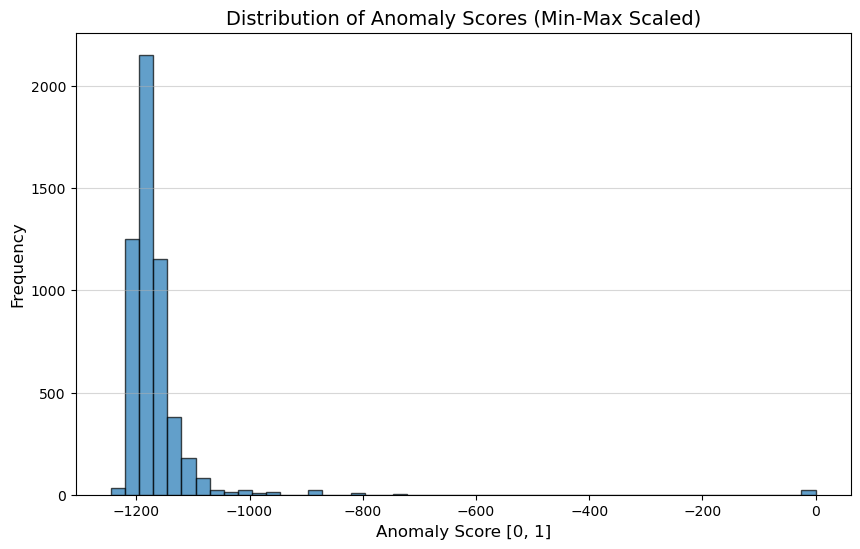

In [28]:
plt.figure(figsize=(10, 6))
plt.hist(raw_anom, bins=50, edgecolor='black', alpha=0.7)
plt.title('Distribution of Anomaly Scores (Min-Max Scaled)', fontsize=14)
plt.xlabel('Anomaly Score [0, 1]', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(axis='y', alpha=0.5)
plt.savefig('anom_score_distribution.png')
print("anom_score_distribution.png saved.")

In [30]:
raw_anom.reshape(-1, 1)

array([[-1150.45745646],
       [-1195.58110523],
       [-1112.51080653],
       ...,
       [-1143.29963443],
       [-1196.70687507],
       [-1165.44618662]], shape=(5370, 1))

In [34]:
from sklearn import preprocessing
scaler = preprocessing.RobustScaler()
robust = scaler.fit_transform(raw_anom.reshape(-1, 1))
robust_df = pd.DataFrame(robust, columns=['x1'])

In [49]:
test = robust.reshape(-1,)

ap = average_precision_score(y_valid["target"], test)
ap

0.3975558429202486

In [50]:
anom_score_clipped = np.clip(test, a_min=None, a_max=1.0)

In [51]:
ap = average_precision_score(y_valid["target"], anom_score_clipped)
ap

0.24494835338864202

In [52]:
# Find the maximum value for scaling purposes, e.g., the 99.9th percentile
# This excludes the most extreme outlier(s)
max_v_capped = np.percentile(raw_anom, 90) 

# Use the capped max for the Min-Max denominator
min_v = np.min(raw_anom)
anom_score_capped = (raw_anom - min_v) / (max_v_capped - min_v + 1e-12)
anom_score_clipp = np.clip(anom_score_capped, a_min=None, a_max=1.0)
ap = average_precision_score(y_valid["target"], anom_score_clipp)
ap

0.2897584647047743

array([0.78372184, 0.40875145, 1.0990525 , ..., 0.84320221, 0.39939648,
       0.65916786], shape=(5370,))

In [57]:
model  = OneClassSVM(
    kernel="rbf",     # RBF works well for non-linear anomalies
    nu=0.05,          # Upper bound on fraction of anomalies in training set
    gamma="scale"     # Kernel coefficient (can tune)
)
preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=True), final_selected_cat_col), #PYOD dont handle spare output
        ("num", StandardScaler(with_mean=False), final_selected_num_col),
        ("bool", "passthrough", final_selected_bool_col),
    ],
    sparse_threshold=1.0,
)
pipe = Pipeline([("prep", preprocess), ("clf", model)])
pipe.fit(X_train_final)



scores_normal = pipe["clf"].score_samples(pipe["prep"].transform(X_valid_final))
raw_anom = -scores_normal  # invert: higher = more anomalous

# Normalize to [0,1]
min_v, max_v = np.min(raw_anom), np.max(raw_anom)
anom_score = (raw_anom - min_v) / (max_v - min_v + 1e-12)

# Evaluation
ap = average_precision_score(y_valid["target"], anom_score)
roc_auc = roc_auc_score(y_valid["target"], anom_score)

In [59]:
scores_normal = pipe["clf"].score_samples(pipe["prep"].transform(X_test_final))
raw_anom = -scores_normal  # invert: higher = more anomalous
min_v, max_v = np.min(raw_anom), np.max(raw_anom)
anom_score = (raw_anom - min_v) / (max_v - min_v + 1e-12)


In [64]:
# ============================================================================
# Test Set Predictions
# ============================================================================
print("\nGenerating test predictions...")

# Transform test data and get scores
test_scores = pipe["clf"].decision_function(pipe["prep"].transform(X_test))

# Convert to [0, 1] anomaly scores
raw_anom_test = -test_scores
min_v, max_v = np.min(raw_anom_test), np.max(raw_anom_test)
test_anom_score = (raw_anom_test - min_v) / (max_v - min_v + 1e-12)

# Create submission
submission = pd.DataFrame({
    'Id': range(len(test_anom_score)),
    'target': test_anom_score
})

submission.to_csv('zi_greedy_features.csv', index=False)
print("Submission saved to 'kait_greedy_features.csv'")
print(f"\nSample predictions:\n{submission.head(10)}")
print(f"Score statistics: min={test_anom_score.min():.4f}, max={test_anom_score.max():.4f}, mean={test_anom_score.mean():.4f}")


Generating test predictions...
Submission saved to 'kait_greedy_features.csv'

Sample predictions:
   Id    target
0   0  0.077917
1   1  0.052459
2   2  0.054835
3   3  0.076023
4   4  0.053688
5   5  0.052459
6   6  0.043672
7   7  0.058655
8   8  0.072113
9   9  0.085691
Score statistics: min=0.0000, max=1.0000, mean=0.0705


In [65]:
from utils import evaluate_outlier_model


selected_bool, selected_cat, selected_num = [], [], []
remaining = cat_col + bool_col + num_col
best_ap = 0
for round_num in range(25):
    best_feature= None
    best_round_ap = best_ap
    
    for feature in remaining:
        model  = LocalOutlierFactor(n_neighbors=8, novelty=True, leaf_size = 15)
        # print(feature)
        type_col = all_feature_dict_copy[feature]
        X_train_current = X_train[selected_bool + selected_cat + selected_num + [feature]]
        X_valid_current = X_valid[selected_bool + selected_cat + selected_num + [feature]]
        # print(X_train_current.head())
        if type_col == "cat":
            ap, roc_auc, scores = evaluate_outlier_model(
                model, X_train_current, X_valid_current, y_valid["target"], selected_cat+[feature], selected_num, selected_bool, True
            )
        elif type_col =="bool":
            ap, roc_auc, scores = evaluate_outlier_model(
                model, X_train_current, X_valid_current, y_valid["target"], selected_cat, selected_num, selected_bool+[feature],  True
            )
        else:
            ap, roc_auc, scores = evaluate_outlier_model(
            model, X_train_current, X_valid_current, y_valid["target"], selected_cat, selected_num+[feature], selected_bool,  True
            )
        if ap > best_round_ap:
                print(f"AP={ap:.4f}, AUC={roc_auc:.4f}")
                best_round_ap = ap
                best_feature = feature
    if best_feature is None:
            print(f"\nNo improvement found. Stopping at {len(selected_bool) + len(selected_cat)+ len(selected_num)} features.")
            break
    type_col = all_feature_dict_copy[best_feature]
    if type_col == "cat":
        selected_cat.append(best_feature)
    elif type_col =="bool":
        selected_bool.append(best_feature)
    else:
        selected_num.append(best_feature)
    remaining.remove(best_feature)
    best_ap = best_round_ap
    
    print(f"Round {round_num+1}: Added '{best_feature}' -> AP={best_ap:.4f}")

AP=0.1261, AUC=0.5000
AP=0.1263, AUC=0.5007
AP=0.1264, AUC=0.5005
AP=0.1280, AUC=0.5022
AP=0.1289, AUC=0.5007
AP=0.1290, AUC=0.5036
AP=0.1338, AUC=0.5056
AP=0.1351, AUC=0.5137
AP=0.1351, AUC=0.5052
AP=0.1506, AUC=0.5140
AP=0.1583, AUC=0.5185
AP=0.1919, AUC=0.5377
Round 1: Added 'pct_months_late' -> AP=0.1919
AP=0.1945, AUC=0.5390
AP=0.2042, AUC=0.5446
AP=0.2099, AUC=0.5548
AP=0.2148, AUC=0.5550
AP=0.2153, AUC=0.5551
AP=0.2176, AUC=0.5884
AP=0.2190, AUC=0.5890
AP=0.2216, AUC=0.5838
AP=0.2231, AUC=0.5352
AP=0.2327, AUC=0.5409
AP=0.2342, AUC=0.5443
AP=0.2551, AUC=0.5525
Round 2: Added '7_8_UPB_Diff' -> AP=0.2551
AP=0.2554, AUC=0.5516
AP=0.2564, AUC=0.5571
AP=0.2601, AUC=0.5547
AP=0.2613, AUC=0.5549
AP=0.2729, AUC=0.5611
AP=0.2798, AUC=0.5648
Round 3: Added '13_CurrentNonInterestBearingUPB' -> AP=0.2798
AP=0.2800, AUC=0.5640
AP=0.2822, AUC=0.5694
AP=0.2836, AUC=0.5735
AP=0.2945, AUC=0.5820
Round 4: Added '0_1_UPB_Diff' -> AP=0.2945
AP=0.2945, AUC=0.5820
AP=0.3002, AUC=0.5888
Round 5: Added

In [72]:
import warnings

# Suppress all warnings
warnings.filterwarnings("ignore")

# Your code that might generate warnings goes here
# ...
# pipe.fit(X_train) 
# ...

# Optional: To restore the default warning behavior afterward
# warnings.filterwarnings("default")

In [73]:
from utils import evaluate_outlier_model


selected_bool, selected_cat, selected_num = [], [], []
remaining = cat_col + bool_col + num_col
best_ap = 0
for round_num in range(25):
    best_feature= None
    best_round_ap = best_ap
    
    for feature in remaining:
        model  = ECOD()
        # print(feature)
        type_col = all_feature_dict_copy[feature]
        X_train_current = X_train[selected_bool + selected_cat + selected_num + [feature]]
        X_valid_current = X_valid[selected_bool + selected_cat + selected_num + [feature]]
        # print(X_train_current.head())
        if type_col == "cat":
            ap, roc_auc, scores = evaluate_outlier_model(
                model, X_train_current, X_valid_current, y_valid["target"], selected_cat+[feature], selected_num, selected_bool, sparse_output=False, ispyod=True
            )
        elif type_col =="bool":
            ap, roc_auc, scores = evaluate_outlier_model(
                model, X_train_current, X_valid_current, y_valid["target"], selected_cat, selected_num, selected_bool+[feature],  sparse_output=False, ispyod=True
            )
        else:
            ap, roc_auc, scores = evaluate_outlier_model(
            model, X_train_current, X_valid_current, y_valid["target"], selected_cat, selected_num+[feature], selected_bool,  sparse_output=False, ispyod=True
            )
        if ap > best_round_ap:
                print(f"AP={ap:.4f}, AUC={roc_auc:.4f}")
                best_round_ap = ap
                best_feature = feature
    if best_feature is None:
            print(f"\nNo improvement found. Stopping at {len(selected_bool) + len(selected_cat)+ len(selected_num)} features.")
            break
    type_col = all_feature_dict_copy[best_feature]
    if type_col == "cat":
        selected_cat.append(best_feature)
    elif type_col =="bool":
        selected_bool.append(best_feature)
    else:
        selected_num.append(best_feature)
    remaining.remove(best_feature)
    best_ap = best_round_ap
    
    print(f"Round {round_num+1}: Added '{best_feature}' -> AP={best_ap:.4f}")

AP=0.1266, AUC=0.5033
AP=0.1329, AUC=0.5280
AP=0.1474, AUC=0.5712
AP=0.1745, AUC=0.5924
AP=0.2026, AUC=0.5846
AP=0.2100, AUC=0.5720
AP=0.3538, AUC=0.6569
Round 1: Added 'pct_months_late' -> AP=0.3538
AP=0.3559, AUC=0.6542
AP=0.3815, AUC=0.6792
Round 2: Added 'HighDTI' -> AP=0.3815
AP=0.3960, AUC=0.6868
Round 3: Added 'HighInterestRate' -> AP=0.3960
AP=0.3961, AUC=0.6868
AP=0.3976, AUC=0.6872
AP=0.3988, AUC=0.6873
AP=0.3989, AUC=0.6873
AP=0.4038, AUC=0.6887
AP=0.4051, AUC=0.6887
Round 4: Added '13_CurrentNonInterestBearingUPB' -> AP=0.4051

No improvement found. Stopping at 4 features.


In [106]:
final_selected_num_col = ["pct_months_late", "13_CurrentNonInterestBearingUPB"]
final_selected_cat_col = []
final_selected_bool_col = ['HighInterestRate', "HighDTI"]
model  = ECOD()
X_train_final = X_train[final_selected_num_col+ final_selected_cat_col+final_selected_bool_col]
X_valid_final = X_valid[final_selected_num_col+ final_selected_cat_col+final_selected_bool_col]
X_test_final = X_test[final_selected_num_col+ final_selected_cat_col+final_selected_bool_col]
ap, roc_auc, scores =evaluate_outlier_model(
model, X_train_final, X_valid_final, y_valid["target"], final_selected_cat_col, final_selected_num_col, final_selected_bool_col,  False, ispyod=True
)
print(ap)

preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), final_selected_cat_col), #PYOD dont handle spare output
        ("num", StandardScaler(with_mean=False), final_selected_num_col),
        ("bool", "passthrough", final_selected_bool_col),
    ],
    sparse_threshold=1.0,
)
pipe = Pipeline([("prep", preprocess), ("clf", model)])
pipe.fit(X_train_final)



scores_normal = pipe["clf"].decision_function(pipe["prep"].transform(X_valid_final))
raw_anom = scores_normal  # invert: higher = more anomalous

# Normalize to [0,1]
min_v, max_v = np.min(raw_anom), np.max(raw_anom)
anom_score = (raw_anom - min_v) / (max_v - min_v + 1e-12)

# Evaluation
ap = average_precision_score(y_valid["target"], anom_score)
roc_auc = roc_auc_score(y_valid["target"], anom_score)

0.40509126294346115


In [107]:
# ============================================================================
# Test Set Predictions
# ============================================================================
print("\nGenerating test predictions...")

# Transform test data and get scores
test_scores = pipe["clf"].decision_function(pipe["prep"].transform(X_test_final))

# Convert to [0, 1] anomaly scores
raw_anom_test = test_scores
min_v, max_v = np.min(raw_anom_test), np.max(raw_anom_test)
test_anom_score = (raw_anom_test - min_v) / (max_v - min_v + 1e-12)

# Create submission
submission = pd.DataFrame({
    'Id': range(len(test_anom_score)),
    'target': test_anom_score
})

submission.to_csv('zi_greedy_features.csv', index=False)
print("Submission saved to 'kait_greedy_features.csv'")
print(f"\nSample predictions:\n{submission.head(10)}")
print(f"Score statistics: min={test_anom_score.min():.4f}, max={test_anom_score.max():.4f}, mean={test_anom_score.mean():.4f}")


Generating test predictions...
Submission saved to 'kait_greedy_features.csv'

Sample predictions:
   Id    target
0   0  0.123593
1   1  0.000000
2   2  0.085817
3   3  0.126591
4   4  0.120044
5   5  0.000000
6   6  0.044001
7   7  0.073589
8   8  0.050004
9   9  0.050004
Score statistics: min=0.0000, max=1.0000, mean=0.0779


In [74]:
from utils import evaluate_outlier_model
from pyod.models.copod import COPOD


selected_bool, selected_cat, selected_num = [], [], []
remaining = cat_col + bool_col + num_col
best_ap = 0
for round_num in range(25):
    best_feature= None
    best_round_ap = best_ap
    
    for feature in remaining:
        model  = COPOD()
        # print(feature)
        type_col = all_feature_dict_copy[feature]
        X_train_current = X_train[selected_bool + selected_cat + selected_num + [feature]]
        X_valid_current = X_valid[selected_bool + selected_cat + selected_num + [feature]]
        # print(X_train_current.head())
        if type_col == "cat":
            ap, roc_auc, scores = evaluate_outlier_model(
                model, X_train_current, X_valid_current, y_valid["target"], selected_cat+[feature], selected_num, selected_bool, sparse_output=False, ispyod=True
            )
        elif type_col =="bool":
            ap, roc_auc, scores = evaluate_outlier_model(
                model, X_train_current, X_valid_current, y_valid["target"], selected_cat, selected_num, selected_bool+[feature],  sparse_output=False, ispyod=True
            )
        else:
            ap, roc_auc, scores = evaluate_outlier_model(
            model, X_train_current, X_valid_current, y_valid["target"], selected_cat, selected_num+[feature], selected_bool,  sparse_output=False, ispyod=True
            )
        if ap > best_round_ap:
                print(f"AP={ap:.4f}, AUC={roc_auc:.4f}")
                best_round_ap = ap
                best_feature = feature
    if best_feature is None:
            print(f"\nNo improvement found. Stopping at {len(selected_bool) + len(selected_cat)+ len(selected_num)} features.")
            break
    type_col = all_feature_dict_copy[best_feature]
    if type_col == "cat":
        selected_cat.append(best_feature)
    elif type_col =="bool":
        selected_bool.append(best_feature)
    else:
        selected_num.append(best_feature)
    remaining.remove(best_feature)
    best_ap = best_round_ap
    
    print(f"Round {round_num+1}: Added '{best_feature}' -> AP={best_ap:.4f}")

AP=0.1266, AUC=0.5033
AP=0.1329, AUC=0.5280
AP=0.1474, AUC=0.5712
AP=0.2323, AUC=0.6548
Round 1: Added 'CreditScore' -> AP=0.2323
AP=0.2426, AUC=0.6821
AP=0.2461, AUC=0.6572
AP=0.2483, AUC=0.6573
AP=0.2730, AUC=0.6641
AP=0.2841, AUC=0.6662
Round 2: Added '13_CurrentNonInterestBearingUPB' -> AP=0.2841
AP=0.2936, AUC=0.6908
AP=0.3123, AUC=0.6632
AP=0.3135, AUC=0.6746
Round 3: Added 'longest_unchanged_UPB' -> AP=0.3135
AP=0.3236, AUC=0.6964
AP=0.3294, AUC=0.6585
Round 4: Added 'pct_months_late' -> AP=0.3294
AP=0.3324, AUC=0.6588
AP=0.3405, AUC=0.6778
Round 5: Added 'HighDTI' -> AP=0.3405
AP=0.3436, AUC=0.6768
AP=0.3495, AUC=0.6870
Round 6: Added 'HighInterestRate' -> AP=0.3495
AP=0.3512, AUC=0.6868
Round 7: Added 'HighLTV' -> AP=0.3512
AP=0.3513, AUC=0.6868
Round 8: Added '10_CurrentNonInterestBearingUPB' -> AP=0.3513

No improvement found. Stopping at 8 features.


In [78]:
from utils import evaluate_outlier_model
from pyod.models.qmcd import QMCD
from pyod.models.kde import KDE
from pyod.models.sampling import Sampling

selected_bool, selected_cat, selected_num = [], [], []
remaining = cat_col + bool_col + num_col
best_ap = 0
for round_num in range(25):
    best_feature= None
    best_round_ap = best_ap
    
    for feature in remaining:
        model  = Sampling()
        # print(feature)
        type_col = all_feature_dict_copy[feature]
        X_train_current = X_train[selected_bool + selected_cat + selected_num + [feature]]
        X_valid_current = X_valid[selected_bool + selected_cat + selected_num + [feature]]
        # print(X_train_current.head())
        if type_col == "cat":
            ap, roc_auc, scores = evaluate_outlier_model(
                model, X_train_current, X_valid_current, y_valid["target"], selected_cat+[feature], selected_num, selected_bool, sparse_output=False, ispyod=True
            )
        elif type_col =="bool":
            ap, roc_auc, scores = evaluate_outlier_model(
                model, X_train_current, X_valid_current, y_valid["target"], selected_cat, selected_num, selected_bool+[feature],  sparse_output=False, ispyod=True
            )
        else:
            ap, roc_auc, scores = evaluate_outlier_model(
            model, X_train_current, X_valid_current, y_valid["target"], selected_cat, selected_num+[feature], selected_bool,  sparse_output=False, ispyod=True
            )
        if ap > best_round_ap:
                print(f"AP={ap:.4f}, AUC={roc_auc:.4f}")
                best_round_ap = ap
                best_feature = feature
    if best_feature is None:
            print(f"\nNo improvement found. Stopping at {len(selected_bool) + len(selected_cat)+ len(selected_num)} features.")
            break
    type_col = all_feature_dict_copy[best_feature]
    if type_col == "cat":
        selected_cat.append(best_feature)
    elif type_col =="bool":
        selected_bool.append(best_feature)
    else:
        selected_num.append(best_feature)
    remaining.remove(best_feature)
    best_ap = best_round_ap
    
    print(f"Round {round_num+1}: Added '{best_feature}' -> AP={best_ap:.4f}")

AP=0.1261, AUC=0.5000
AP=0.1268, AUC=0.5028
AP=0.1272, AUC=0.5045
AP=0.1751, AUC=0.5897
AP=0.3070, AUC=0.6265
Round 1: Added 'pct_months_late' -> AP=0.3070
AP=0.3198, AUC=0.6663
AP=0.3302, AUC=0.6483
AP=0.3690, AUC=0.6629
AP=0.3952, AUC=0.6875
AP=0.3966, AUC=0.7237
Round 2: Added 'longest_unchanged_UPB' -> AP=0.3966
AP=0.3971, AUC=0.7253
Round 3: Added '1_MonthlyReportingPeriod' -> AP=0.3971
AP=0.4059, AUC=0.7266
Round 4: Added 'EstimatedLTV_all_MissFlag' -> AP=0.4059
AP=0.4083, AUC=0.7144
AP=0.4106, AUC=0.7399
Round 5: Added '12_MonthlyReportingPeriod' -> AP=0.4106
AP=0.4122, AUC=0.7159
Round 6: Added 'CreditScore' -> AP=0.4122
AP=0.4288, AUC=0.7256
Round 7: Added '6_CurrentNonInterestBearingUPB' -> AP=0.4288

No improvement found. Stopping at 7 features.


In [105]:
final_selected_num_col = ["pct_months_late", "longest_unchanged_UPB", "1_MonthlyReportingPeriod", "12_MonthlyReportingPeriod", 'CreditScore', '6_CurrentNonInterestBearingUPB']
final_selected_cat_col = []
final_selected_bool_col = ['EstimatedLTV_all_MissFlag']
model  = Sampling()
X_train_final = X_train[final_selected_num_col+ final_selected_cat_col+final_selected_bool_col]
X_valid_final = X_valid[final_selected_num_col+ final_selected_cat_col+final_selected_bool_col]
X_test_final = X_test[final_selected_num_col+ final_selected_cat_col+final_selected_bool_col]
ap, roc_auc, scores =evaluate_outlier_model(
model, X_train_final, X_valid_final, y_valid["target"], final_selected_cat_col, final_selected_num_col, final_selected_bool_col,  False, ispyod=True
)
print(ap)

preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), final_selected_cat_col), #PYOD dont handle spare output
        ("num", StandardScaler(with_mean=False), final_selected_num_col),
        ("bool", "passthrough", final_selected_bool_col),
    ],
    sparse_threshold=1.0,
)
pipe = Pipeline([("prep", preprocess), ("clf", model)])
pipe.fit(X_train_final)



scores_normal = pipe["clf"].decision_function(pipe["prep"].transform(X_valid_final))
raw_anom = scores_normal  # invert: higher = more anomalous

# Normalize to [0,1]
min_v, max_v = np.min(raw_anom), np.max(raw_anom)
anom_score = (raw_anom - min_v) / (max_v - min_v + 1e-12)

# Evaluation
ap = average_precision_score(y_valid["target"], anom_score)
roc_auc = roc_auc_score(y_valid["target"], anom_score)

0.3641307936463237


In [ ]:
# ============================================================================
# Test Set Predictions
# ============================================================================
print("\nGenerating test predictions...")

# Transform test data and get scores
test_scores = pipe["clf"].decision_function(pipe["prep"].transform(X_test))

# Convert to [0, 1] anomaly scores
raw_anom_test = -test_scores
min_v, max_v = np.min(raw_anom_test), np.max(raw_anom_test)
test_anom_score = (raw_anom_test - min_v) / (max_v - min_v + 1e-12)

# Create submission
submission = pd.DataFrame({
    'Id': range(len(test_anom_score)),
    'target': test_anom_score
})

submission.to_csv('zi_greedy_features.csv', index=False)
print("Submission saved to 'kait_greedy_features.csv'")
print(f"\nSample predictions:\n{submission.head(10)}")
print(f"Score statistics: min={test_anom_score.min():.4f}, max={test_anom_score.max():.4f}, mean={test_anom_score.mean():.4f}")

In [79]:
from utils import evaluate_outlier_model
from pyod.models.qmcd import QMCD
from pyod.models.kde import KDE
from pyod.models.sampling import Sampling
from pyod.models.gmm import GMM


selected_bool, selected_cat, selected_num = [], [], []
remaining = cat_col + bool_col + num_col
best_ap = 0
for round_num in range(25):
    best_feature= None
    best_round_ap = best_ap
    
    for feature in remaining:
        model  = GMM()
        # print(feature)
        type_col = all_feature_dict_copy[feature]
        X_train_current = X_train[selected_bool + selected_cat + selected_num + [feature]]
        X_valid_current = X_valid[selected_bool + selected_cat + selected_num + [feature]]
        # print(X_train_current.head())
        if type_col == "cat":
            ap, roc_auc, scores = evaluate_outlier_model(
                model, X_train_current, X_valid_current, y_valid["target"], selected_cat+[feature], selected_num, selected_bool, sparse_output=False, ispyod=True
            )
        elif type_col =="bool":
            ap, roc_auc, scores = evaluate_outlier_model(
                model, X_train_current, X_valid_current, y_valid["target"], selected_cat, selected_num, selected_bool+[feature],  sparse_output=False, ispyod=True
            )
        else:
            ap, roc_auc, scores = evaluate_outlier_model(
            model, X_train_current, X_valid_current, y_valid["target"], selected_cat, selected_num+[feature], selected_bool,  sparse_output=False, ispyod=True
            )
        if ap > best_round_ap:
                print(f"AP={ap:.4f}, AUC={roc_auc:.4f}")
                best_round_ap = ap
                best_feature = feature
    if best_feature is None:
            print(f"\nNo improvement found. Stopping at {len(selected_bool) + len(selected_cat)+ len(selected_num)} features.")
            break
    type_col = all_feature_dict_copy[best_feature]
    if type_col == "cat":
        selected_cat.append(best_feature)
    elif type_col =="bool":
        selected_bool.append(best_feature)
    else:
        selected_num.append(best_feature)
    remaining.remove(best_feature)
    best_ap = best_round_ap
    
    print(f"Round {round_num+1}: Added '{best_feature}' -> AP={best_ap:.4f}")

AP=0.1266, AUC=0.5033
AP=0.1329, AUC=0.5280
AP=0.1474, AUC=0.5712
AP=0.2155, AUC=0.6038
AP=0.3067, AUC=0.6510
Round 1: Added 'pct_months_late' -> AP=0.3067
AP=0.3110, AUC=0.6752
AP=0.3182, AUC=0.6595
AP=0.3322, AUC=0.6651
AP=0.3426, AUC=0.6957
Round 2: Added 'longest_unchanged_UPB' -> AP=0.3426
AP=0.3440, AUC=0.6917
AP=0.3518, AUC=0.7089
AP=0.3557, AUC=0.7035
AP=0.3765, AUC=0.7051
Round 3: Added 'CreditScore' -> AP=0.3765
AP=0.3765, AUC=0.7051
AP=0.3792, AUC=0.7061
AP=0.3825, AUC=0.7202
AP=0.3872, AUC=0.7073
AP=0.3904, AUC=0.7075
Round 4: Added '13_CurrentNonInterestBearingUPB' -> AP=0.3904
AP=0.3904, AUC=0.7075
AP=0.3931, AUC=0.7085
AP=0.3960, AUC=0.7224
Round 5: Added 'HighDTI' -> AP=0.3960
AP=0.3990, AUC=0.7222
AP=0.3991, AUC=0.7313
Round 6: Added 'HighInterestRate' -> AP=0.3991
AP=0.4015, AUC=0.7322
Round 7: Added 'HighLTV' -> AP=0.4015

No improvement found. Stopping at 7 features.


In [62]:
X_test[["Id"]]

KeyError: "None of [Index(['Id'], dtype='object')] are in the [columns]"

In [60]:
x_test_final = test_df_dropped[["Id"]]
x_test_final["target"]= anom_score
x_test_final.to_csv("output.csv", index=False)

NameError: name 'test_df_dropped' is not defined

In [41]:
X_train[final_selected_num_col+ final_selected_cat_col+ final_selected_bool_col]

,pct_months_late,10_RemainingMonthsToLegalMaturity,13_CurrentNonInterestBearingUPB,LoanPurpose,CreditScore_is_outlier,HighRiskCredit,HighInterestRate,HighDTI
0,0.428571,350,0.0,P,False,0,1,0
1,0.357143,350,0.0,P,False,0,1,0
2,0.357143,350,0.0,C,False,0,1,0
3,0.500000,350,0.0,P,False,0,1,1
4,0.500000,350,0.0,C,False,0,1,0
...,...,...,...,...,...,...,...,...
30499,0.428571,350,0.0,N,False,0,1,0
30500,0.285714,350,0.0,P,False,0,0,1
30501,0.428571,350,0.0,P,False,0,0,0
30502,0.357143,350,0.0,P,False,0,0,0


In [ ]:
def greedy_forward_selection(X_train, X_valid, y_valid, all_features, max_features=25):
    """
    Greedily add features one by one to maximize AP.
    """
    selected = []
    remaining = all_features.copy()
    best_ap = 0
    
    num_pipeline = Pipeline([
        ("scaler", MinMaxScaler())
    ])

    preprocess = ColumnTransformer(
        transformers=[("num", num_pipeline, all_features)],
        sparse_threshold=1.0,
    )
    
    X_train_prep = preprocess.fit_transform(X_train[all_features])
    X_valid_prep = preprocess.transform(X_valid[all_features])
    
    if issparse(X_train_prep):
        X_train_prep = X_train_prep.toarray()
        X_valid_prep = X_valid_prep.toarray()
    
    feature_to_idx = {f: i for i, f in enumerate(all_features)}
    
    print("Starting forward feature selection...\n")
    
    for round_num in range(max_features):
        best_feature = None
        best_round_ap = best_ap
        
        for feature in remaining:
            # Try adding this feature
            test_features = selected + [feature]
            test_indices = [feature_to_idx[f] for f in test_features]
            
            X_train_test = X_train_prep[:, test_indices]
            X_valid_test = X_valid_prep[:, test_indices]
            
            # Train and evaluate
            ocsvm = COPOD()
            ocsvm.fit(X_train_test)
            
            scores = ocsvm.decision_function(X_valid_test)
            # raw_anom = -scores
            min_v, max_v = np.min(scores), np.max(scores)
            anom_score = (scores - min_v) / (max_v - min_v + 1e-12)
            
            ap = average_precision_score(y_valid["target"], anom_score)
            roc_auc = roc_auc_score(y_valid["target"], anom_score)

            if ap > best_round_ap:
                print(f"AP={ap:.4f}, AUC={roc_auc:.4f}")
                best_round_ap = ap
                best_feature = feature
        
        if best_feature is None:
            print(f"\nNo improvement found. Stopping at {len(selected)} features.")
            break
        
        selected.append(best_feature)
        remaining.remove(best_feature)
        best_ap = best_round_ap
        
        print(f"Round {round_num+1}: Added '{best_feature}' -> AP={best_ap:.4f}")
    
    return selected

# Run forward selection
selected_features = greedy_forward_selection(X_train, X_valid, y_valid, num_col, max_features=15)
print(f"\nFinal selected features: {selected_features}")



In [ ]:
bool_col = []
cat_col = []
num_col = ['pct_months_late', '12_RemainingMonthsToLegalMaturity', 'repayment_trend_slope', 'CreditScore_DTI_Ratio', '3_4_UPB_Diff', '4_5_UPB_Diff', '13_CurrentNonInterestBearingUPB', 'UPB_std']

In [220]:
X_train = train_data[cat_col + num_col + bool_col]
X_valid = valid_data[cat_col + num_col + bool_col]
X_test = test_data.drop(columns="Id")

y_valid = valid_data[['index', 'target']]
out = ['index', 'target']
y_valid = valid_data[out]

In [221]:
import numpy as np
import pandas as pd
from sklearn.pipeline import Pipeline
from category_encoders import BinaryEncoder
from sklearn.preprocessing import StandardScaler, OneHotEncoder, MinMaxScaler
from sklearn.compose import ColumnTransformer
from sklearn.metrics import average_precision_score, roc_auc_score
from sklearn.svm import OneClassSVM


# ============================================================================
# Preprocessing Pipeline
# ============================================================================
num_pipeline = Pipeline([
    ("scaler", MinMaxScaler())
])


preprocess = ColumnTransformer(
    transformers=[
        ("num", num_pipeline, num_col),
        ("cat", BinaryEncoder(handle_unknown="ignore"), cat_col),
        ("bool", "passthrough", bool_col),
    ],
    sparse_threshold=1.0,
)

# ============================================================================
# One-Class SVM Model
# ============================================================================

ocsvm = OneClassSVM(
    kernel='rbf',
    nu=0.0001,  # Expected outlier fraction - tune this!
    gamma='auto',  # RBF kernel parameter
)

# Build pipeline
pipe = Pipeline([
    ("prep", preprocess), 
    ("clf", ocsvm)
])

# ============================================================================
# Training (on normal data only)
# ============================================================================
print("Training One-Class SVM on normal data...")
pipe.fit(X_train)

# ============================================================================
# Validation (for hyperparameter tuning)
# ============================================================================
print("\nEvaluating on validation set...")

# Get anomaly scores
scores = pipe["clf"].decision_function(pipe["prep"].transform(X_valid))

# Convert to [0, 1] range where 1 = anomaly
# One-Class SVM: positive scores = normal, negative = anomaly
# We negate and normalize
raw_anom = -scores  # Now higher = more anomalous

# Min-max normalization to [0, 1]
min_v, max_v = np.min(raw_anom), np.max(raw_anom)
anom_score = (raw_anom - min_v) / (max_v - min_v + 1e-12)

# Store scores
y_valid = y_valid.copy()
y_valid["anom_score"] = anom_score

# Compute metrics
ap = average_precision_score(y_valid["target"], y_valid["anom_score"])
roc_auc = roc_auc_score(y_valid["target"], y_valid["anom_score"])

print(f"Average Precision: {ap:.4f}")
print(f"AUC-ROC: {roc_auc:.4f}")

# ============================================================================
# Hyperparameter Tuning on Validation Set
# ============================================================================
def tune_hyperparameters(X_train, X_valid, y_valid, preprocess):
    """
    Grid search for optimal hyperparameters.
    Focus on nu and gamma which are most critical.
    """
    best_ap = 0
    best_params = None
    best_scores = None
    
    # Hyperparameter grid
    nu_list = [0.0001, 0.0003,0.0005, 0.001, 0.005, 0.01]
    gamma_list = ['scale', 'auto', 0.001, 0.01, 0.1]
    
    print("Starting hyperparameter tuning...\n")
    
    for nu in nu_list:
        for gamma in gamma_list:
            # Create model
            ocsvm = OneClassSVM(
                kernel='rbf',
                nu=nu,
                gamma=gamma,
            )
            
            pipe = Pipeline([("prep", preprocess), ("clf", ocsvm)])
            
            # Train and evaluate
            pipe.fit(X_train)
            scores = pipe["clf"].decision_function(pipe["prep"].transform(X_valid))
            
            raw_anom = -scores
            min_v, max_v = np.min(raw_anom), np.max(raw_anom)
            anom_score = (raw_anom - min_v) / (max_v - min_v + 1e-12)
            
            ap = average_precision_score(y_valid["target"], anom_score)
            roc_auc = roc_auc_score(y_valid["target"], anom_score)
            
            print(f"nu={nu:.3f}, gamma={gamma} -> AP={ap:.4f}, AUC={roc_auc:.4f}")
            
            if ap > best_ap:
                best_ap = ap
                best_params = {'nu': nu, 'gamma': gamma}
                best_scores = {'ap': ap, 'auc': roc_auc}
    
    print(f"\nBest parameters: {best_params}")
    print(f"Best AP: {best_scores['ap']:.4f}, AUC: {best_scores['auc']:.4f}")
    return best_params

# Uncomment to run tuning:
best_params = tune_hyperparameters(X_train, X_valid, y_valid, preprocess)

# ============================================================================
# Retrain with best parameters (after tuning)
# ============================================================================
# After tuning, use best parameters:
print(best_params)
ocsvm = OneClassSVM(kernel='rbf', nu=best_params['nu'], gamma=best_params['gamma'])
pipe = Pipeline([("prep", preprocess), ("clf", ocsvm)])
pipe.fit(X_train)


Training One-Class SVM on normal data...

Evaluating on validation set...
Average Precision: 0.4382
AUC-ROC: 0.7291
Starting hyperparameter tuning...

nu=0.000, gamma=scale -> AP=0.2955, AUC=0.6467
nu=0.000, gamma=auto -> AP=0.4382, AUC=0.7291
nu=0.000, gamma=0.001 -> AP=0.3540, AUC=0.6970
nu=0.000, gamma=0.01 -> AP=0.4406, AUC=0.7340
nu=0.000, gamma=0.1 -> AP=0.4393, AUC=0.7304
nu=0.000, gamma=scale -> AP=0.2954, AUC=0.6468
nu=0.000, gamma=auto -> AP=0.4235, AUC=0.7182
nu=0.000, gamma=0.001 -> AP=0.4387, AUC=0.7264
nu=0.000, gamma=0.01 -> AP=0.4339, AUC=0.7247
nu=0.000, gamma=0.1 -> AP=0.4261, AUC=0.7199
nu=0.001, gamma=scale -> AP=0.3013, AUC=0.6512
nu=0.001, gamma=auto -> AP=0.4215, AUC=0.7106
nu=0.001, gamma=0.001 -> AP=0.4267, AUC=0.7158
nu=0.001, gamma=0.01 -> AP=0.4300, AUC=0.7164
nu=0.001, gamma=0.1 -> AP=0.4235, AUC=0.7116
nu=0.001, gamma=scale -> AP=0.3626, AUC=0.6842
nu=0.001, gamma=auto -> AP=0.4316, AUC=0.7133
nu=0.001, gamma=0.001 -> AP=0.4480, AUC=0.7248
nu=0.001, gamma=

Pipeline(steps=[('prep',
                 ColumnTransformer(sparse_threshold=1.0,
                                   transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   MinMaxScaler())]),
                                                  ['pct_months_late',
                                                   '12_RemainingMonthsToLegalMaturity',
                                                   'repayment_trend_slope',
                                                   'CreditScore_DTI_Ratio',
                                                   '3_4_UPB_Diff',
                                                   '4_5_UPB_Diff',
                                                   '13_CurrentNonInterestBearingUPB',
                                                   'UPB_std']),
                                                 ('cat',
                                                  BinaryEncoder(handle_unknown='ignore'),
                                                  []),
                                                 ('bool', 'passthrough', [])])),
                ('clf', OneClassSVM(gamma=0.001, nu=0.001))])

In [222]:
# ============================================================================
# Test Set Predictions
# ============================================================================
print("\nGenerating test predictions...")

# Transform test data and get scores
test_scores = pipe["clf"].decision_function(pipe["prep"].transform(X_test))

# Convert to [0, 1] anomaly scores
raw_anom_test = -test_scores
min_v, max_v = np.min(raw_anom_test), np.max(raw_anom_test)
test_anom_score = (raw_anom_test - min_v) / (max_v - min_v + 1e-12)

# Create submission
submission = pd.DataFrame({
    'Id': range(len(test_anom_score)),
    'target': test_anom_score
})

submission.to_csv('kait_greedy_features.csv', index=False)
print("Submission saved to 'kait_greedy_features.csv'")
print(f"\nSample predictions:\n{submission.head(10)}")
print(f"Score statistics: min={test_anom_score.min():.4f}, max={test_anom_score.max():.4f}, mean={test_anom_score.mean():.4f}")


Generating test predictions...
Submission saved to 'kait_greedy_features.csv'

Sample predictions:
   Id    target
0   0  0.000364
1   1  0.000325
2   2  0.000313
3   3  0.000337
4   4  0.000274
5   5  0.000326
6   6  0.000297
7   7  0.000328
8   8  0.000358
9   9  0.000363
Score statistics: min=0.0000, max=1.0000, mean=0.0036


In [223]:
submission

,Id,target
0,0,0.000364
1,1,0.000325
2,2,0.000313
3,3,0.000337
4,4,0.000274
...,...,...
13421,13421,0.000329
13422,13422,0.000316
13423,13423,0.000364
13424,13424,0.000370


In [224]:
y_pred = pipe["clf"].predict(pipe["prep"].transform(X_valid))
y_pred_binary = (y_pred == -1).astype(int)  # Convert to 1 for anomaly, 0 for normal


In [225]:
y_pred_binary

array([0, 0, 0, ..., 0, 0, 0])

In [226]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report

print("Accuracy:", accuracy_score(y_valid.target, y_pred_binary))
print("Precision:", precision_score(y_valid.target, y_pred_binary))
print("Recall:", recall_score(y_valid.target, y_pred_binary))
print("F1 Score:", f1_score(y_valid.target, y_pred_binary))
print("ROC-AUC:", roc_auc_score(y_valid.target, y_pred_binary))
print("\nConfusion Matrix:\n", confusion_matrix(y_valid.target, y_pred_binary))
print("\nClassification Report:\n", classification_report(y_valid.target, y_pred_binary))


Accuracy: 0.8888268156424581
Precision: 0.925531914893617
Recall: 0.12850812407680945
F1 Score: 0.22568093385214008
ROC-AUC: 0.5635082704338873

Confusion Matrix:
 [[4686    7]
 [ 590   87]]

Classification Report:
               precision    recall  f1-score   support

         0.0       0.89      1.00      0.94      4693
         1.0       0.93      0.13      0.23       677

    accuracy                           0.89      5370
   macro avg       0.91      0.56      0.58      5370
weighted avg       0.89      0.89      0.85      5370

